# Análise de perguntas de negócio - Passos Mágicos

Este notebook responde às 11 perguntas de negócio do Datathon utilizando o datasset consolidado e limpo gerado no notebook de `01_eda.ipynb`.

**Perguntas respondidas:**
1. Adequação do nível (IAN)
2. Desempenho acadêmico (IDA)
3. Engajamento nas atividades (IEG)
4. Autoavaliação (IAA)
5. Aspectos psicossociais (IPS)
6. Aspectos psicopedagógicos (IPP)
7. Ponto de virada (IPV)
8. Multidimensionalidade dos indicadores
9. Previsão de risco (preview)
10. Efetividade do programa
11. Insights adicionais (criatividade)

# 0. Setup

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../reports', exist_ok=True)

# Paleta de cores padrão do projeto
COR_QUARTZO   = '#95A5A6'
COR_AGATA     = '#2ECC71'
COR_AMETISTA  = '#9B59B6'
COR_TOPAZIO   = '#3498DB'
COR_RISCO     = '#E74C3C'
COR_OK        = '#2ECC71'
CORES_PEDRA   = [COR_QUARTZO, COR_AGATA, COR_AMETISTA, COR_TOPAZIO]
CORES_ANOS    = ['#4C72B0', '#DD8452', '#55A868']

In [84]:
# Carregar dataset limpo 
df = pd.read_parquet('../data/processed/pede_consolidado.parquet')

indicadores  = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

# Garantir tipos
df['PEDRA'] = pd.Categorical(df['PEDRA'], categories=ordem_pedras, ordered=True)
df['ANO']   = df['ANO'].astype(int)

print(f'Dataset carregado: {df.shape}')
print(df['ANO'].value_counts().sort_index())

Dataset carregado: (3030, 22)
ANO
2022     860
2023    1014
2024    1156
Name: count, dtype: int64


---
# P1: Adequação ao Nível (IAN)

> *Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo do ano?*

**Contexto metodológico:** O IAN é quasi-binário (assume predominantemente os valores 5 e 10). Para tornar a análise de defasagem mais informativa, utilizamos também a coluna `DEFASAGEM` (gap entre fase atual e fase ideal), que captura gradações que o IAN não captura.

In [85]:
# Feature: IAN_ADEQUADO (binária, mais informativa que o IAN contínuo)
df['IAN_ADEQUADO'] = (df['IAN'] > 7).astype(int)

# Classificação de defasagem pelo IAN
def classificar_ian(val):
    if pd.isna(val):
        return 'Sem dados'
    elif val <= 5.0:
        return 'Severa (≤5)'
    elif val <= 7.0:
        return 'Moderada (5–7)'
    else:
        return 'Adequada (>7)'

df['DEFASAGEM_IAN'] = df['IAN'].apply(classificar_ian)
ordem_def  = ['Severa (≤5)', 'Moderada (5–7)', 'Adequada (>7)']
cores_def  = ['#E74C3C', '#F39C12', '#2ECC71']

print('Distribuição por categoria de defasagem:')
print(df['DEFASAGEM_IAN'].value_counts())

Distribuição por categoria de defasagem:
DEFASAGEM_IAN
Severa (≤5)      1687
Adequada (>7)    1343
Name: count, dtype: int64


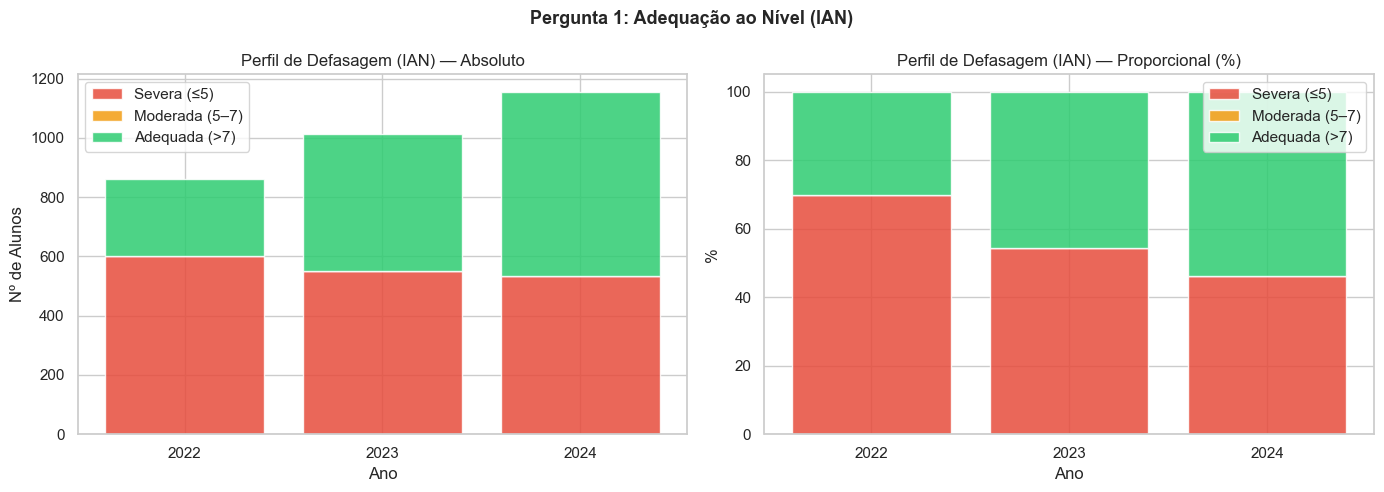

In [86]:
tabela = df.groupby(['ANO', 'DEFASAGEM_IAN']).size().reset_index(name='Qtde')
tabela['Prop'] = tabela.groupby('ANO')['Qtde'].transform(lambda x: x / x.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 1: Adequação ao Nível (IAN)', fontsize=13, fontweight='bold')

# Absoluto (barras empilhadas)
bottom_abs = np.zeros(3)
anos = [2022, 2023, 2024]
for cor, cat in zip(cores_def, ordem_def):
    vals = [tabela[(tabela['ANO'] == a) & (tabela['DEFASAGEM_IAN'] == cat)]['Qtde'].values[0]
            if len(tabela[(tabela['ANO'] == a) & (tabela['DEFASAGEM_IAN'] == cat)]) > 0 else 0
            for a in anos]
    axes[0].bar(anos, vals, bottom=bottom_abs, label=cat, color=cor, alpha=0.85)
    bottom_abs += np.array(vals)

axes[0].set_title('Perfil de Defasagem (IAN) — Absoluto')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Nº de Alunos')
axes[0].set_xticks([2022, 2023, 2024])
axes[0].legend()

# Proporcional
bottom_prop = np.zeros(3)
for cor, cat in zip(cores_def, ordem_def):
    vals = [tabela[(tabela['ANO'] == a) & (tabela['DEFASAGEM_IAN'] == cat)]['Prop'].values[0]
            if len(tabela[(tabela['ANO'] == a) & (tabela['DEFASAGEM_IAN'] == cat)]) > 0 else 0
            for a in anos]
    axes[1].bar(anos, vals, bottom=bottom_prop, label=cat, color=cor, alpha=0.85)
    bottom_prop += np.array(vals)

axes[1].set_title('Perfil de Defasagem (IAN) — Proporcional (%)')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('%')
axes[1].set_xticks([2022, 2023, 2024])
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/P01_defasagem_IAN.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

* O IAN é quasi-binário: praticamente todos os alunos se concentram em `"Adequada (>7)"`, com as categorias `Severa`e `Moderada`quase invisíveis. Isso não significa ausência de defasagem, significa que o IAN não captura gradações.

* A proporção de alunos `Adequados`cresceu de 30% (2022) para mais ou menos 55% (2024), tendência positiva consistente em termos absolutos.

* Limitação metodológica: para análises de defasagem real, é melhor utilizar a coluna `DEFASAGEM` (gap fase atual vs. ideal) em lugar do IAN, pois ela é mais granular.

* Para o modelo preditivo: criar `IAN_ADEQUADO`como feature binária (IAN > 7) em vez de usar o valor contínuo, evitando o efeito de step function artificial.

---
# P2: Desempenho Acadêmico (IDA)

> *O IDA está melhorando, estagnado ou caindo ao longo das fases e anos?*

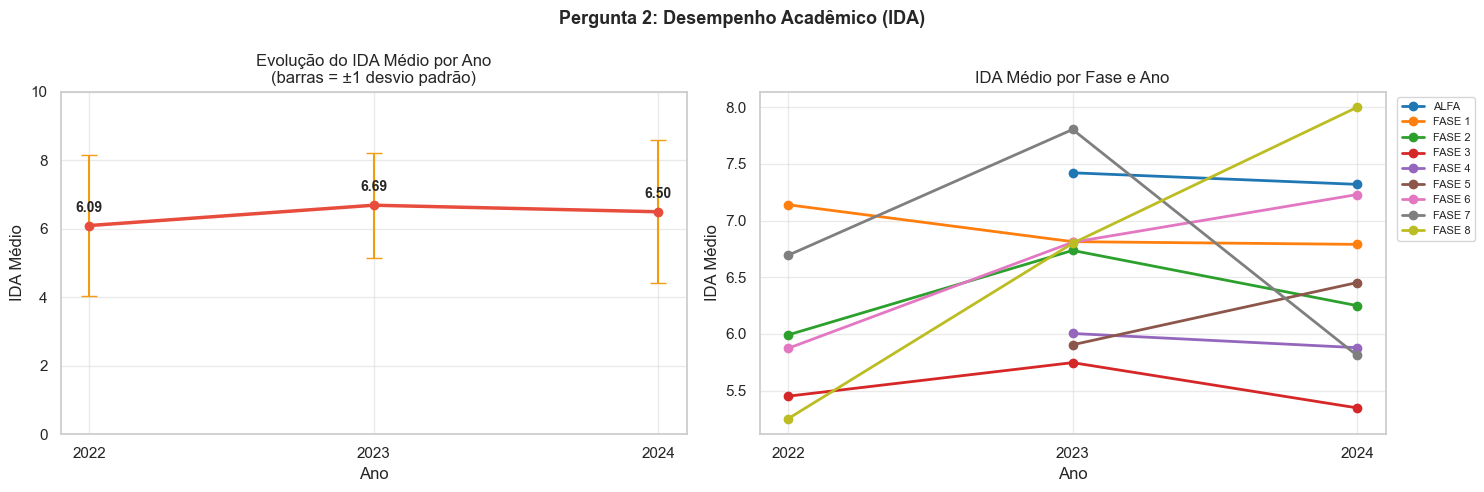

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pergunta 2: Desempenho Acadêmico (IDA)', fontsize=13, fontweight='bold')

# Evolução geral com desvio padrão
ida_ano = df.groupby('ANO')['IDA'].agg(['mean', 'std']).reset_index()
axes[0].errorbar(ida_ano['ANO'], ida_ano['mean'], yerr=ida_ano['std'],
                 marker='o', linewidth=2.5, capsize=6, color=COR_RISCO,
                 ecolor='#F39C12', elinewidth=1.5)
for _, row in ida_ano.iterrows():
    axes[0].annotate(f"{row['mean']:.2f}",
                     xy=(row['ANO'], row['mean']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Evolução do IDA Médio por Ano\n(barras = ±1 desvio padrão)')
axes[0].set_xticks([2022, 2023, 2024])
axes[0].set_ylim(0, 10)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('IDA Médio')
axes[0].grid(True, alpha=0.4)

# IDA por Fase e Ano
fases_validas = [f for f in ['ALFA','FASE 1','FASE 2','FASE 3','FASE 4',
                              'FASE 5','FASE 6','FASE 7','FASE 8']
                 if f in df['FASE'].unique()]
ida_fase = df[df['FASE'].isin(fases_validas)].groupby(['ANO', 'FASE'])['IDA'].mean().reset_index()

cores_fases = plt.cm.tab10.colors
for i, fase in enumerate(fases_validas):
    sub = ida_fase[ida_fase['FASE'] == fase]
    if len(sub) > 0:
        axes[1].plot(sub['ANO'], sub['IDA'], marker='o', label=fase,
                     color=cores_fases[i % 10], linewidth=2)

axes[1].set_title('IDA Médio por Fase e Ano')
axes[1].set_xticks([2022, 2023, 2024])
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('IDA Médio')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/P02_desempenho_IDA.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

* Veredicto: estagnado. O alto desvio padrão revela enorme heterogeneidade interna que a média esconde.

* FASE 8: crescimento expressivo de 2022 para 2024. Único grupo com melhora consistente, sugerindo que o programa é mais efetivo nas fases avançadas.

* FASE 3: queda consistente nos 3 anos. É a fase com pior trajetória, candidata prioritária a intervenção pedagógica específica.

* FASE 7: pico em 2023 com queda acentuada em 2024. Sinal de alerta a investigar.

* ALFA: dados apenas a partir de 2023, com IDA alto para o grupo de entrada, pode indicar critérios de admissão efetivos ou avaliação diferenciada.

* Implicação: o IDA não melhora no agregado, mas esconde trajetórias opostas por fase. Fases intermediárias (3 e 4) regridem enquanto fases avançadas (7 e 8) progridem.

---
# P3: Engajamento nas Atividades (IEG)

> *O IEG tem relação direta com IDA e IPV?*

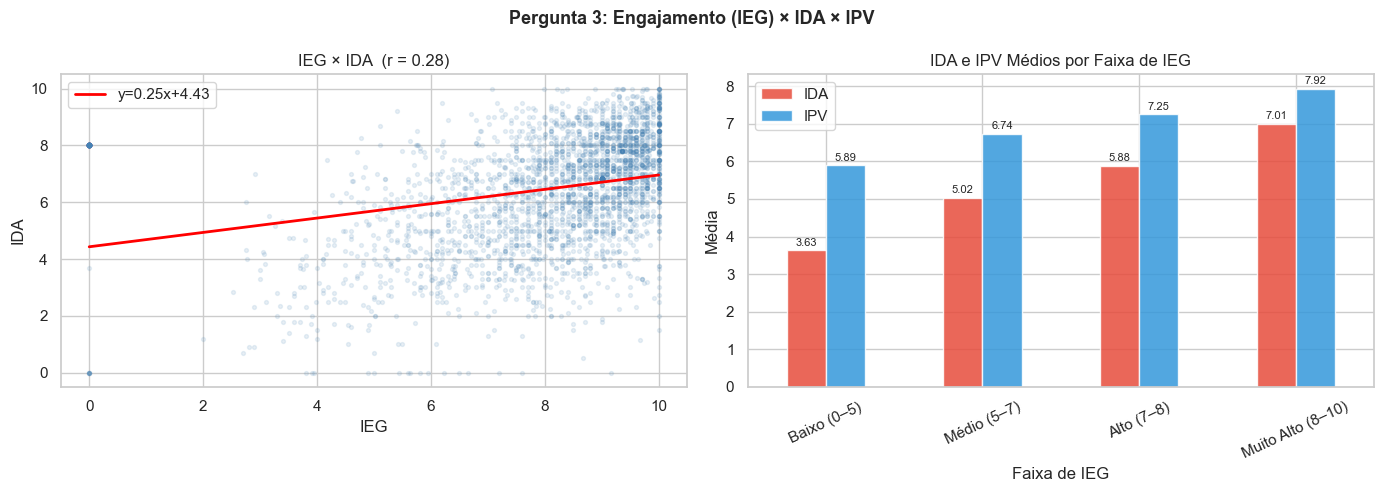

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 3: Engajamento (IEG) × IDA × IPV', fontsize=13, fontweight='bold')

# Scatter IEG × IDA com regressão
df_scatter = df[['IEG', 'IDA']].dropna()
axes[0].scatter(df_scatter['IEG'], df_scatter['IDA'],
                alpha=0.12, color='steelblue', s=8)
m, b = np.polyfit(df_scatter['IEG'], df_scatter['IDA'], 1)
x_line = np.linspace(df_scatter['IEG'].min(), df_scatter['IEG'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2,
             label=f'y={m:.2f}x+{b:.2f}')
corr_ida = df_scatter['IEG'].corr(df_scatter['IDA'])
axes[0].set_title(f'IEG × IDA  (r = {corr_ida:.2f})')
axes[0].set_xlabel('IEG')
axes[0].set_ylabel('IDA')
axes[0].legend()

# IDA e IPV médios por faixa de IEG
df['IEG_FAIXA'] = pd.cut(df['IEG'], bins=[0, 5, 7, 8, 10],
                          labels=['Baixo (0–5)', 'Médio (5–7)',
                                  'Alto (7–8)', 'Muito Alto (8–10)'])
medias = df.groupby('IEG_FAIXA', observed=True)[['IDA', 'IPV']].mean()
medias.plot(kind='bar', ax=axes[1], color=[COR_RISCO, COR_TOPAZIO],
            edgecolor='white', alpha=0.85)
axes[1].set_title('IDA e IPV Médios por Faixa de IEG')
axes[1].set_xlabel('Faixa de IEG')
axes[1].set_ylabel('Média')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('../reports/P03_engajamento_IEG.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

* Correlação IEGxIDA moderada-fraca. Engajamento e desempenho são dimensões parcialmente independentes, aluno engajado não necessariamente tem bom desempenho e vice-versa. Isso confirma que as duas features têm valor preditivo complementar no modelo.

* O IPV responde ao IEG de forma mais sensível que o IDA: do IEG Baixo para Muito Alto, a diferença é de +3,4 pontos no IDA e +2,0 pontos no IPV, mas o IPV parte de um valor menor e termina mais próximo do IDA, indicando maior sensibilidade relativa.

* Alunos com IEG baixo (0-5) têm IDA médio de apenas 3.6, menor subgrupo de desempenho. Aumentar o engajamento desse grupo tem impacto duplo: melhora desempenho e aproxima do ponto de virada.

* A nuvem de pontos no scatter revela um cluster de alunos com IEG=0, mesmos alunos com IAA=0, provavelmente ausentes ou sem avaliação. Esses casos devem ser tratados como categoria separada.

---
# P4: Autoavaliação (IAA)
> *As percepções dos alunos sobre si mesmos são coerentes com desempenho real e engajamento?*

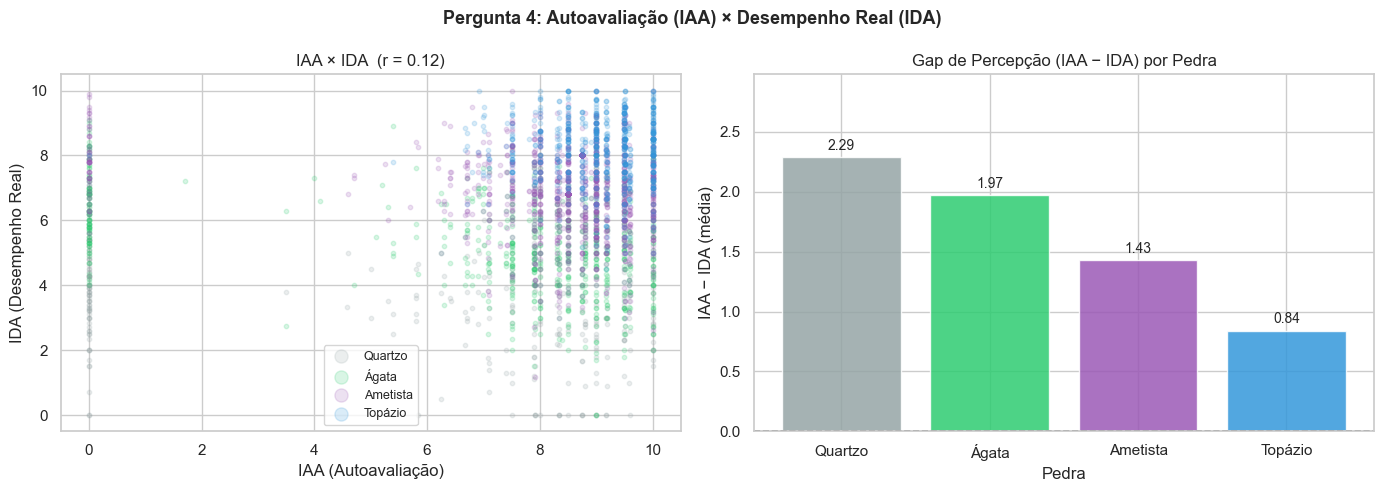

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 4: Autoavaliação (IAA) × Desempenho Real (IDA)',
             fontsize=13, fontweight='bold')

# Scatter IAA × IDA colorido por Pedra
cores_pedra_dict = dict(zip(ordem_pedras, CORES_PEDRA))
for pedra, cor in cores_pedra_dict.items():
    sub = df[df['PEDRA'] == pedra]
    axes[0].scatter(sub['IAA'], sub['IDA'], alpha=0.18,
                    color=cor, label=pedra, s=10)

corr_iaa_ida = df[['IAA', 'IDA']].corr().iloc[0, 1]
axes[0].set_title(f'IAA × IDA  (r = {corr_iaa_ida:.2f})')
axes[0].set_xlabel('IAA (Autoavaliação)')
axes[0].set_ylabel('IDA (Desempenho Real)')
axes[0].legend(markerscale=3, fontsize=9)

# Gap IAA - IDA por Pedra
df['GAP_IAA_IDA'] = df['IAA'] - df['IDA']
gap_pedra = df.groupby('PEDRA', observed=True)['GAP_IAA_IDA'].mean().reset_index()
cores_list = [cores_pedra_dict[p] for p in gap_pedra['PEDRA'].values]
bars = axes[1].bar(gap_pedra['PEDRA'], gap_pedra['GAP_IAA_IDA'],
                   color=cores_list, edgecolor='white', alpha=0.85)
axes[1].bar_label(bars, fmt='%.2f', fontsize=10, padding=3)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('Gap de Percepção (IAA − IDA) por Pedra')
axes[1].set_xlabel('Pedra')
axes[1].set_ylabel('IAA − IDA (média)')
axes[1].set_ylim(0, gap_pedra['GAP_IAA_IDA'].max() * 1.3)

plt.tight_layout()
plt.savefig('../reports/P04_autoavaliacao_IAA.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- Correlação IAA×IDA praticamente nula. A autopercepção do aluno não reflete seu desempenho real de forma consistente, a autoavaliação é um indicador de estado emocional/motivacional, não de competência acadêmica.

- Todos os grupos têm gap positivo (IAA > IDA): todos os alunos se avaliam acima do desempenho real, mas com intensidades diferentes:
  - Quartzo: +2,3 pontos (maior otimismo, pior desempenho)
  - Ágata: +1,9 pontos
  - Ametista: +1,4 pontos
  - Topázio: +0,9 pontos (mais realistas, melhor desempenho)

- Relação inversa entre desempenho e calibração: alunos em risco superestimam suas habilidades em 2,5x mais que alunos Topázio. Isso é pedagogicamente crítico: alunos em risco podem não perceber a necessidade de intervenção.

- Implicação prática: o programa deve incorporar mecanismos de feedback estruturado que calibrem a autopercepção, especialmente para Quartzo e Ágata. Alunos que não reconhecem sua defasagem têm menor adesão a atividades de reforço.

---
# P5: Aspectos Psicossociais (IPS)
> *Há padrões psicossociais que antecedem quedas de desempenho ou engajamento?*

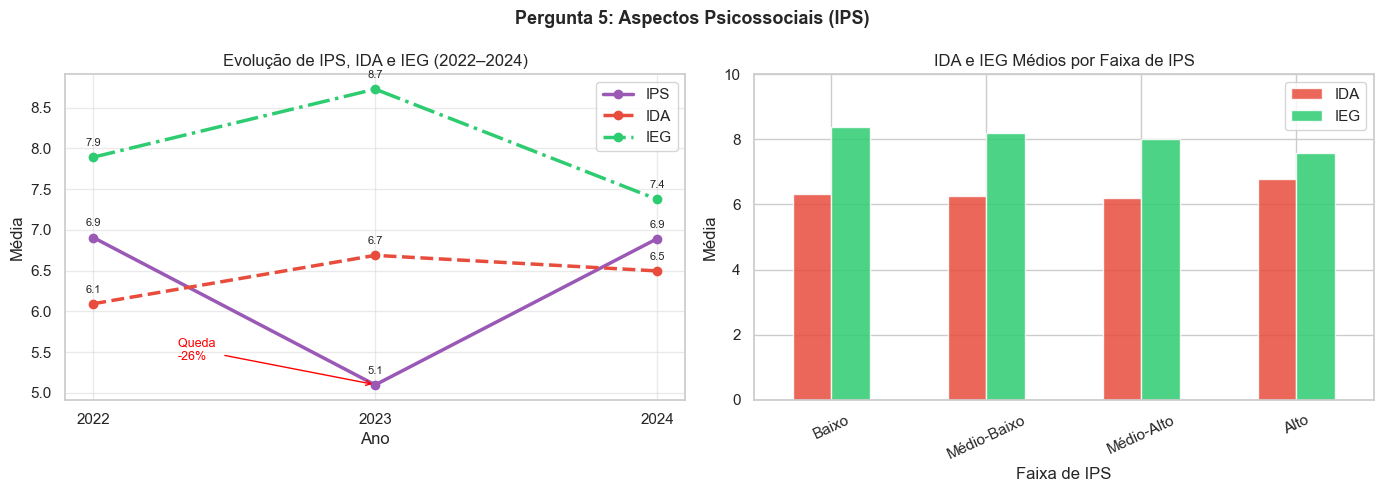

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 5: Aspectos Psicossociais (IPS)',
             fontsize=13, fontweight='bold')

# Evolução IPS, IDA e IEG por ano
ips_ano = df.groupby('ANO')[['IPS', 'IDA', 'IEG']].mean().reset_index()
for col, cor, ls in zip(['IPS', 'IDA', 'IEG'],
                         ['#9B59B6', COR_RISCO, '#2ECC71'],
                         ['-', '--', '-.']):
    axes[0].plot(ips_ano['ANO'], ips_ano[col], marker='o',
                 label=col, color=cor, linewidth=2.5, linestyle=ls)
    for _, row in ips_ano.iterrows():
        axes[0].annotate(f"{row[col]:.1f}",
                         xy=(row['ANO'], row[col]),
                         xytext=(0, 8), textcoords='offset points',
                         ha='center', fontsize=8)

axes[0].set_title('Evolução de IPS, IDA e IEG (2022–2024)')
axes[0].set_xticks([2022, 2023, 2024])
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Média')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Anotação da queda do IPS em 2023
axes[0].annotate('Queda \n-26%', xy=(2023, 5.1),
                  xytext=(2022.3, 5.4),
                  arrowprops=dict(arrowstyle='->', color='red'),
                  color='red', fontsize=9)

# IDA e IEG por faixa de IPS
df['IPS_FAIXA'] = pd.cut(df['IPS'], bins=[0, 5, 6.25, 7.5, 10],
                          labels=['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto'])
ips_ida = df.groupby('IPS_FAIXA', observed=True)[['IDA', 'IEG']].mean()
ips_ida.plot(kind='bar', ax=axes[1], color=[COR_RISCO, '#2ECC71'],
             edgecolor='white', alpha=0.85)
axes[1].set_title('IDA e IEG Médios por Faixa de IPS')
axes[1].set_xlabel('Faixa de IPS')
axes[1].set_ylabel('Média')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('../reports/P05_psicossocial_IPS.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- Queda do IPS em 2023 (-26%) é o maior evento do dataset: de 6,9 para 5,1 em um único ano, com recuperação total em 2024. A simetria perfeita do "V" levanta hipótese de mudança metodológica na coleta, verificar com a equipe antes de atribuir a fenômeno externo.

- IDA e IEG praticamente não se moveram em 2023 apesar da queda do IPS: isso sugere que o programa funciona como *fator protetor*, consegue manter desempenho e engajamento mesmo em contexto psicossocial adverso. É o resultado mais positivo e inesperado do projeto.

- Gráfico direito: IPS não prediz IDA nem IEG. IDA permanece em mais ou menos 6,2 em todas as faixas de IPS. IEG cai levemente com IPS mais alto (contraintuitivo). O IPS captura uma dimensão estruturalmente diferente dos demais indicadores.

- Implicação: o IPS tem baixo valor como feature isolada para o modelo preditivo, mas pode ter efeito de interação com tempo (defasagem temporal) que não aparece na análise bivariada.

---
# P6: Aspectos Psicopedagógicos (IPP)
> *As avaliações psicopedagógicas confirmam ou contradizem a defasagem identificada pelo IAN?*

**Nota:** IPP disponível apenas para 2023 e 2024 (ausente em 2022 por design).

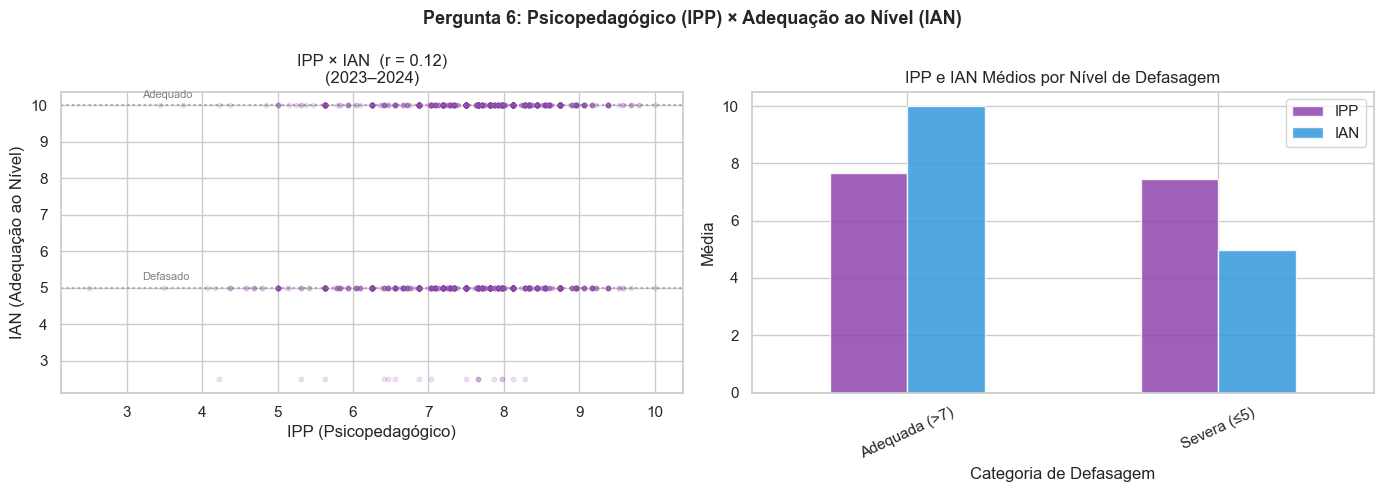

In [91]:
df_ipp = df[df['ANO'].isin([2023, 2024])].copy()
df_ipp['DEFASAGEM_IAN'] = df_ipp['IAN'].apply(classificar_ian)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 6: Psicopedagógico (IPP) × Adequação ao Nível (IAN)',
             fontsize=13, fontweight='bold')

# Scatter IPP × IAN
axes[0].scatter(df_ipp['IPP'], df_ipp['IAN'],
                alpha=0.15, color='#8E44AD', s=10)
corr_ipp_ian = df_ipp[['IPP', 'IAN']].corr().iloc[0, 1]
axes[0].set_title(f'IPP × IAN  (r = {corr_ipp_ian:.2f})\n(2023–2024)')
axes[0].set_xlabel('IPP (Psicopedagógico)')
axes[0].set_ylabel('IAN (Adequação ao Nível)')

# Adicionar linhas de referência nos valores dominantes do IAN
for val, label in [(5, 'Defasado'), (10, 'Adequado')]:
    axes[0].axhline(val, color='gray', linestyle=':', alpha=0.6)
    axes[0].text(3.2, val + 0.2, label, fontsize=8, color='gray')

# IPP e IAN por categoria de defasagem (somente categorias com dados)
cats_com_dados = df_ipp.groupby('DEFASAGEM_IAN').size()
cats_validas   = cats_com_dados[cats_com_dados > 0].index.tolist()
medias_pp = df_ipp[df_ipp['DEFASAGEM_IAN'].isin(cats_validas)].groupby('DEFASAGEM_IAN')[['IPP', 'IAN']].mean()

if len(medias_pp) > 0:
    medias_pp.plot(kind='bar', ax=axes[1],
                   color=['#8E44AD', COR_TOPAZIO],
                   edgecolor='white', alpha=0.85)
    axes[1].set_title('IPP e IAN Médios por Nível de Defasagem')
    axes[1].set_xlabel('Categoria de Defasagem')
    axes[1].set_ylabel('Média')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Dados insuficientes\npor categoria',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('../reports/P06_psicopedagogico_IPP.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- O scatter IPP×IAN confirma visualmente a natureza binária do IAN: pontos concentrados em IAN=5 e IAN=10, com IPP variando continuamente em toda a faixa, ou seja, o IPP não consegue predizer se o aluno está adequado ao nível.

- Correlação IPP×IAN de apenas 0,12: as avaliações psicopedagógicas e a adequação ao nível são dimensões independentes, o IPP mede algo diferente da defasagem curricular.

- IPP confirma IPV, não o IAN: a correlação mais relevante do IPP no dataset é com o Ponto de Virada (0,61), não com a adequação ao nível. O suporte psicopedagógico impacta a transformação do aluno, não sua classificação curricular.

- Recomendação para a ONG: usar o IPP como indicador de prontidão para transformação (IPV), não como validação da defasagem curricular (IAN). São objetivos distintos que requerem instrumentos distintos.

---
# P7: Ponto de Virada (IPV)
> *Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?*

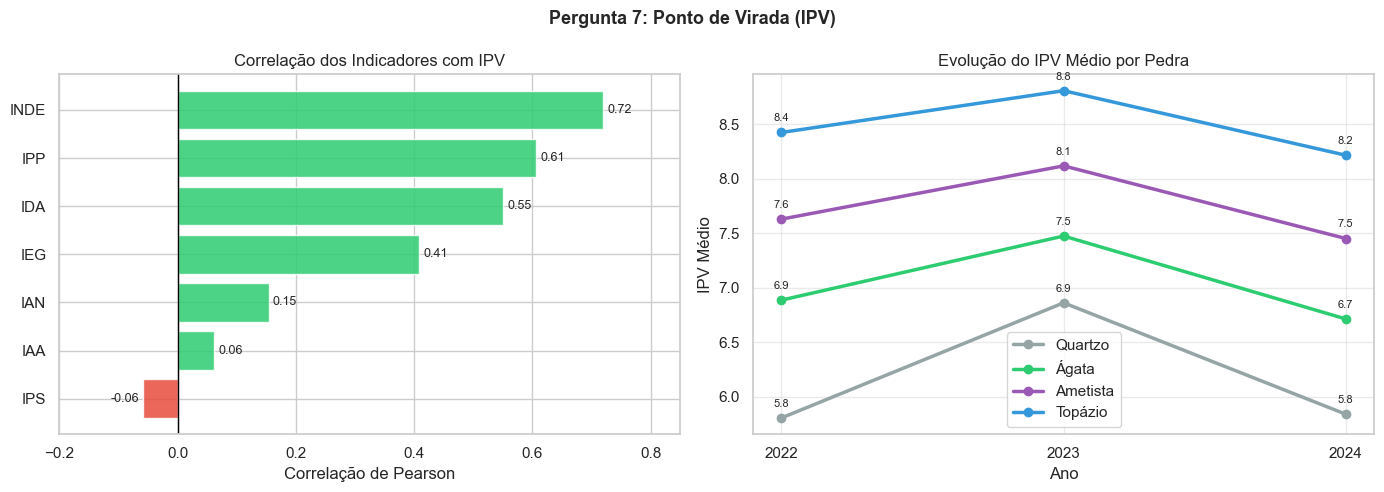

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 7: Ponto de Virada (IPV)', fontsize=13, fontweight='bold')

# Correlação de cada indicador com IPV
feats_ipv = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'INDE']
corrs_ipv = df[feats_ipv].corrwith(df['IPV']).sort_values(ascending=True)
cores_corr = [COR_RISCO if v < 0 else '#2ECC71' for v in corrs_ipv]

bars = axes[0].barh(corrs_ipv.index, corrs_ipv.values,
                    color=cores_corr, edgecolor='white', alpha=0.85)
axes[0].bar_label(bars, fmt='%.2f', fontsize=9, padding=3)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Correlação dos Indicadores com IPV')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].set_xlim(-0.2, 0.85)

# Evolução do IPV médio por Pedra e Ano
ipv_pedra = df.groupby(['ANO', 'PEDRA'], observed=True)['IPV'].mean().reset_index()
for pedra, cor in zip(ordem_pedras, CORES_PEDRA):
    sub = ipv_pedra[ipv_pedra['PEDRA'] == pedra]
    if len(sub) > 0:
        axes[1].plot(sub['ANO'], sub['IPV'], marker='o',
                     label=pedra, color=cor, linewidth=2.5)
        for _, row in sub.iterrows():
            axes[1].annotate(f"{row['IPV']:.1f}",
                             xy=(row['ANO'], row['IPV']),
                             xytext=(0, 8), textcoords='offset points',
                             ha='center', fontsize=8)

axes[1].set_title('Evolução do IPV Médio por Pedra')
axes[1].set_xticks([2022, 2023, 2024])
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('IPV Médio')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/P07_ponto_virada_IPV.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- Ranking de influência no IPV: O INDE é co-dependente por construção; entre os indicadores independentes, IPP é o preditor mais forte do IPV.

- IPS negativo (-0,06): condição psicossocial não prediz o ponto de virada, alunos transformam suas vidas independentemente do contexto socioeconômico adverso. Resultado poderoso para o storytelling.

- Padrão "montanha" em 2023 para todos os grupos: IPV peak em 2023 e queda em 2024. Isso é sistêmico, não comportamento individual. 
    - *Hipótese: critério de avaliação do IPV foi revisado em 2024 ou houve mudança na metodologia de aplicação.*

- Quartzo cai mais acentuadamente em 2024: grupo de risco ficando ainda mais distante do ponto de virada, sinal de que a intervenção atual não está alcançando esses alunos de forma efetiva.

---
# P8: Multidimensionalidade dos Indicadores
> *Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?*

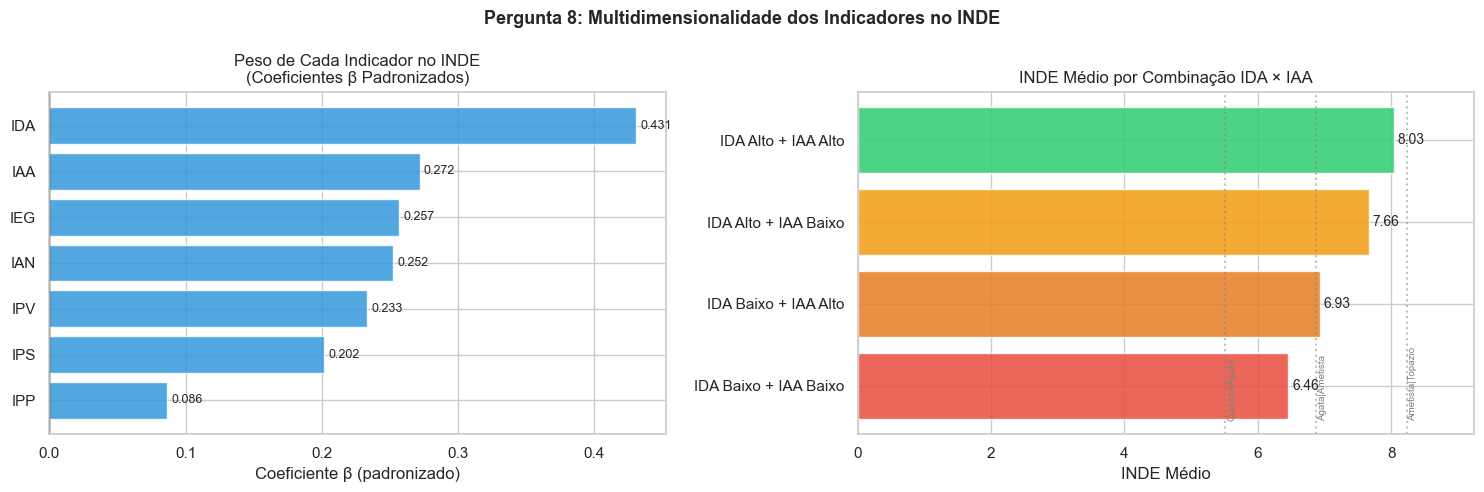

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pergunta 8: Multidimensionalidade dos Indicadores no INDE',
             fontsize=13, fontweight='bold')

# Importância via regressão linear padronizada
feats_reg = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
df_reg = df[feats_reg + ['INDE']].dropna()
X = StandardScaler().fit_transform(df_reg[feats_reg])
y = df_reg['INDE'].values

reg  = LinearRegression().fit(X, y)
coefs = pd.Series(reg.coef_, index=feats_reg).sort_values(ascending=True)
cores_coef = [COR_RISCO if v < 0 else COR_TOPAZIO for v in coefs]

bars = axes[0].barh(coefs.index, coefs.values,
                    color=cores_coef, edgecolor='white', alpha=0.85)
axes[0].bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Peso de Cada Indicador no INDE\n(Coeficientes β Padronizados)')
axes[0].set_xlabel('Coeficiente β (padronizado)')

# INDE médio por combinação IDA × IAA
df['IDA_ALTO'] = df['IDA'] >= df['IDA'].median()
df['IAA_ALTO'] = df['IAA'] >= df['IAA'].median()
df['COMBO'] = (df['IDA_ALTO'].map({True: 'IDA Alto', False: 'IDA Baixo'}) +
               ' + ' +
               df['IAA_ALTO'].map({True: 'IAA Alto', False: 'IAA Baixo'}))

combo_inde = df.groupby('COMBO')['INDE'].mean().sort_values(ascending=True)
cores_combo = [COR_RISCO, '#E67E22', '#F39C12', '#2ECC71']

bars2 = axes[1].barh(combo_inde.index, combo_inde.values,
                     color=cores_combo, edgecolor='white', alpha=0.85)
axes[1].bar_label(bars2, fmt='%.2f', fontsize=10, padding=3)
axes[1].set_title('INDE Médio por Combinação IDA × IAA')
axes[1].set_xlabel('INDE Médio')
axes[1].set_xlim(0, combo_inde.max() * 1.15)

# Linhas das faixas de Pedra
for limiar, label in [(5.506, 'Quartzo|Ágata'), (6.868, 'Ágata|Ametista'), (8.230, 'Ametista|Topázio')]:
    axes[1].axvline(limiar, color='gray', linestyle=':', alpha=0.5)
    axes[1].text(limiar + 0.02, -0.4, label, fontsize=7, color='gray', rotation=90)

plt.tight_layout()
plt.savefig('../reports/P08_multidimensionalidade_INDE.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- Ranking β padronizado: IDA tem peso 2x maior que qualquer outro indicador no INDE.

- IAA, IEG, IAN e IPV têm pesos similares (0,23–0,27): quando controlados simultaneamente, contribuem de forma equilibrada. O IPS tem peso relevante (0,20) apesar da baixa correlação bivariada — efeito de supressão/confounding entre variáveis.

- IPP tem o menor peso (0,09): possivelmente por ser disponível apenas em 2 dos 3 anos, reduzindo seu sinal relativo.

- A autoestima importa, mas não substitui o desempenho. Um aluno com bom desempenho e autoestima baixa (7,66) ainda supera um com boa autoestima mas desempenho baixo (6,93) em 0,73 pontos.

- Implicação para features do modelo: usar todos os indicadores disponíveis, não apenas IDA e IEG. Os pesos similares de IAA, IAN e IPV indicam que o modelo preditivo se beneficia da multidimensionalidade.

---
# P9: Previsão de Risco (Preview do Modelo)
> *Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho?*

**Nota:** O modelo completo de ML está no notebook `03_model.ipynb`. Aqui criamos a variável alvo e mostramos o perfil dos grupos.

In [94]:
# Definir variável alvo RISCO
# Critério: PEDRA == Quartzo OU INDE abaixo do percentil 25
# Justificativa: captura tanto a classificação formal (Pedra) quanto
# alunos que, mesmo em outras pedras, estão no quartil inferior de desenvolvimento

p25 = df['INDE'].quantile(0.25)
df['RISCO'] = ((df['PEDRA'] == 'Quartzo') | (df['INDE'] < p25)).astype(int)

print(f"Percentil 25 do INDE: {p25:.3f}")
print(f"\nDistribuição da variável alvo RISCO:")
print(df['RISCO'].value_counts())
print(f"\nTaxa de risco geral: {df['RISCO'].mean()*100:.1f}%")
print(f"\nTaxa de risco por ano:")
print((df.groupby('ANO')['RISCO'].mean() * 100).round(1))

Percentil 25 do INDE: 6.721

Distribuição da variável alvo RISCO:
RISCO
0    2272
1     758
Name: count, dtype: int64

Taxa de risco geral: 25.0%

Taxa de risco por ano:
ANO
2022    32.4
2023    22.7
2024    21.5
Name: RISCO, dtype: float64


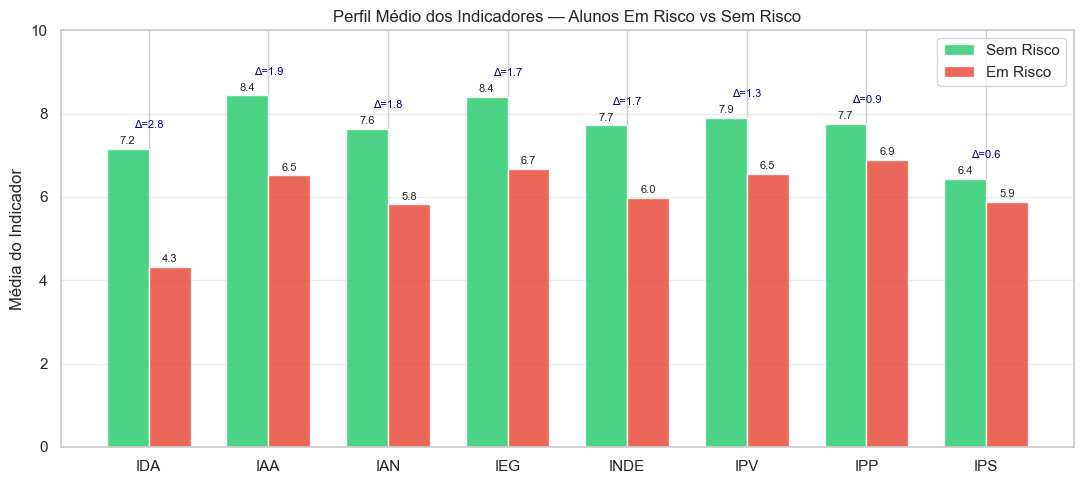


Diferença entre grupos (Sem Risco - Em Risco):
IDA     2.84
IAA     1.92
IAN     1.81
IEG     1.75
INDE    1.74
IPV     1.34
IPP     0.86
IPS     0.55
Name: Diferença, dtype: float64


In [95]:
# Perfil médio dos indicadores por grupo de risco
perfil = df.groupby('RISCO')[indicadores].mean().T
perfil.columns = ['Sem Risco (0)', 'Em Risco (1)']
perfil['Diferença'] = perfil['Sem Risco (0)'] - perfil['Em Risco (1)']
perfil = perfil.sort_values('Diferença', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(perfil))
w = 0.35
bars1 = ax.bar(x - w/2, perfil['Sem Risco (0)'], w,
               label='Sem Risco', color=COR_OK, edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + w/2, perfil['Em Risco (1)'], w,
               label='Em Risco', color=COR_RISCO, edgecolor='white', alpha=0.85)

ax.bar_label(bars1, fmt='%.1f', fontsize=8, padding=2)
ax.bar_label(bars2, fmt='%.1f', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(perfil.index)
ax.set_ylabel('Média do Indicador')
ax.set_title('Perfil Médio dos Indicadores — Alunos Em Risco vs Sem Risco')
ax.legend()
ax.grid(axis='y', alpha=0.4)
ax.set_ylim(0, 10)

# Anotar diferença
for i, (idx, row) in enumerate(perfil.iterrows()):
    ax.text(i, max(row['Sem Risco (0)'], row['Em Risco (1)']) + 0.5,
            f'Δ={row["Diferença"]:.1f}', ha='center', fontsize=8, color='navy')

plt.tight_layout()
plt.savefig('../reports/P09_perfil_risco.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDiferença entre grupos (Sem Risco - Em Risco):")
print(perfil['Diferença'].sort_values(ascending=False).round(2))

**Insights:**

- IDA tem a maior separação entre grupos: é o indicador que mais discrimina alunos em risco dos sem risco, confirma seu papel central no modelo preditivo.

- IPS tem o menor poder discriminativo: condição psicossocial quase não diferencia os dois grupos, baixo valor como feature isolada.

- Nenhum indicador chega a zero no grupo de risco: o risco é multidimensional, não causado por colapso de um único fator. Isso reforça a necessidade de um modelo que combine múltiplas features.

- Perfil do aluno em risco: IDA≈4,3, IAA≈6,5, IAN≈5,9, IEG≈6,7. Features mais promissoras para o modelo: IDA, IAA, IAN e IEG (maior poder discriminativo e complementaridade).

---
# P10: Efetividade do Programa
> *Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo → Topázio)?*

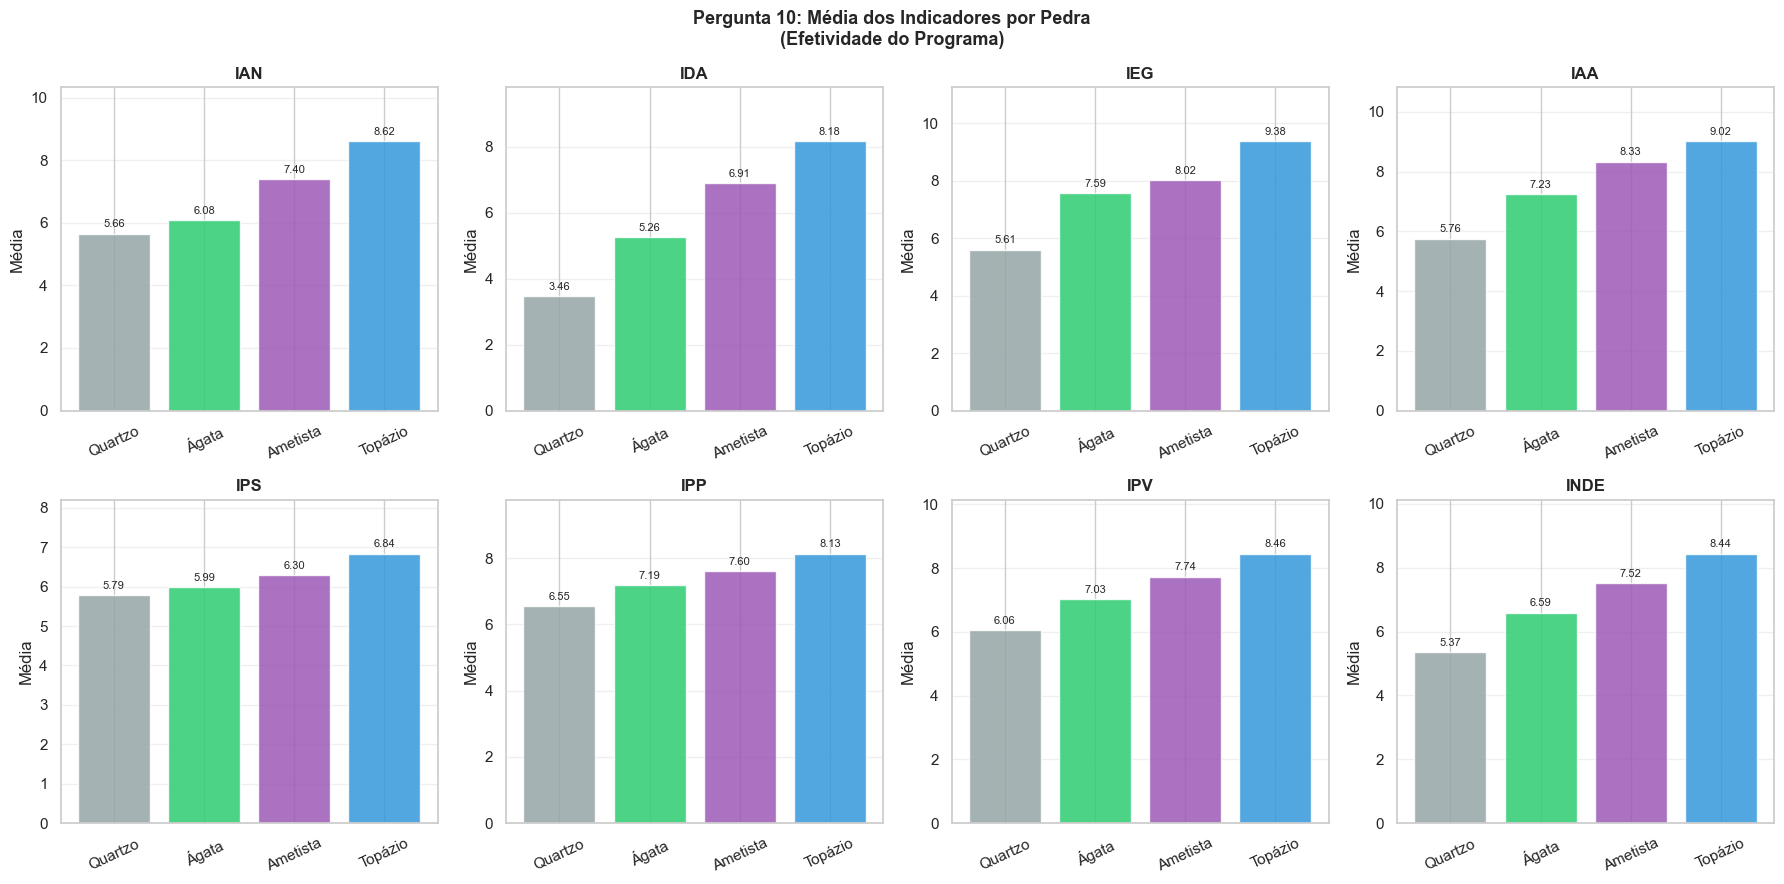

In [96]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle('Pergunta 10: Média dos Indicadores por Pedra\n(Efetividade do Programa)',
             fontsize=13, fontweight='bold')

for i, col in enumerate(indicadores):
    medias = df.groupby('PEDRA', observed=True)[col].mean()
    bars = axes[i].bar(medias.index, medias.values,
                       color=CORES_PEDRA, edgecolor='white', alpha=0.85)
    axes[i].bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Média')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].set_ylim(0, medias.max() * 1.2)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/P10_efetividade_programa.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- Veredicto: o programa é efetivo. Todos os 8 indicadores crescem monotonicamente de Quartzo para Topázio, a classificação por Pedra captura uma progressão real e multidimensional do desenvolvimento.

- IDA tem a maior amplitude: Quartzo (3,46) → Topázio (8,18). É o indicador que mais diferencia os grupos e o que mais impacta a progressão de Pedra.

- IEG Topázio chega a 9,38, próximo do teto. Alto engajamento é a característica mais marcante dos alunos de melhor desempenho, mais que qualquer outro indicador não-IDA.

- IPS tem a menor amplitude: Quartzo (5,79) → Topázio (6,84). Condição psicossocial diferencia pouco os grupos, o programa gera resultados independentemente do contexto social do aluno.

- IPP Quartzo (6,55): alunos em risco recebem suporte psicopedagógico com IPP já razoável, mas sem resultado no INDE, sugere necessidade de abordagem diferenciada, não apenas mais do mesmo suporte.

- Implicação estratégica: o desafio não é o topo da pirâmide (Topázio está bem), mas acelerar a progressão Ágata→Ametista→Topázio via IDA, o principal gargalo identificado.

---
# P11: Insights Adicionais (Criatividade)
> *Insights e pontos de vista não abordados nas perguntas anteriores.*

### P11a: Taxa de Ponto de Virada por Pedra

**Nota:** PONTO_VIRADA disponível apenas em 2022 (True/False). Em 2023 e 2024 o campo não foi preenchido na base de dados.

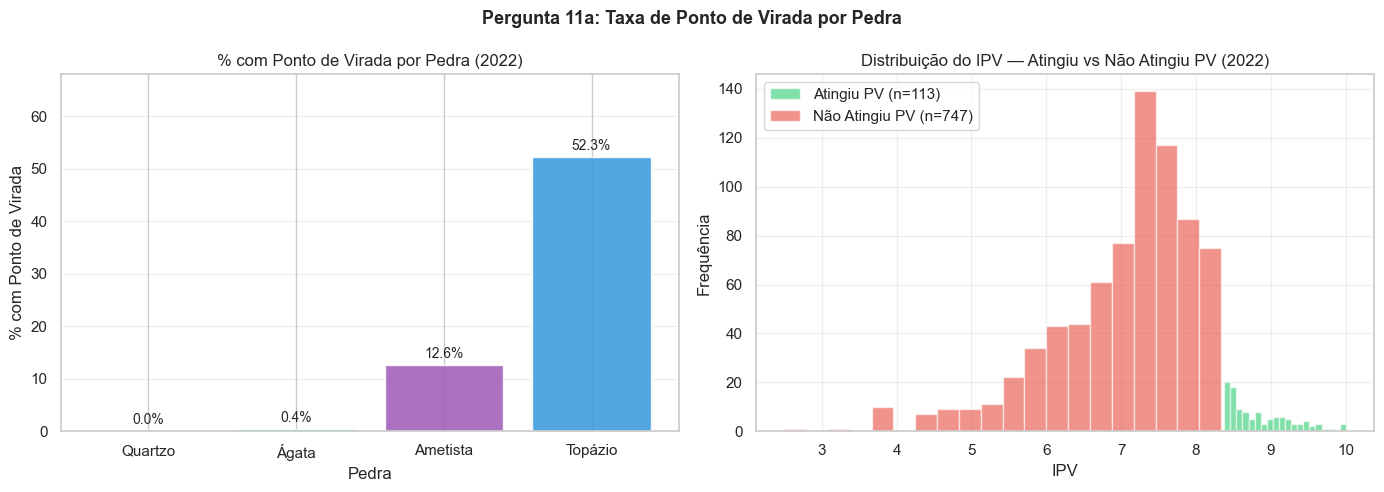

Alunos com PV=True em 2022: 113
Taxa geral 2022: 13.1%

IPV médio por grupo (2022):
PONTO_VIRADA
False    7.01
True     8.86
Name: IPV, dtype: float64


In [97]:
if 'PONTO_VIRADA' in df.columns:
    df_pv = df[df['PONTO_VIRADA'].notna()].copy()

    if len(df_pv) > 0:
        pv = df_pv.groupby(['ANO', 'PEDRA'], observed=True)['PONTO_VIRADA'].mean().reset_index()
        pv['%PV'] = pv['PONTO_VIRADA'] * 100

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Pergunta 11a: Taxa de Ponto de Virada por Pedra',
                     fontsize=13, fontweight='bold')

        # Barras por Pedra
        pedras_pv = pv.groupby('PEDRA', observed=True)['%PV'].mean().reset_index()
        cores_list = [dict(zip(ordem_pedras, CORES_PEDRA)).get(p, 'gray')
                      for p in pedras_pv['PEDRA'].values]
        bars = axes[0].bar(pedras_pv['PEDRA'], pedras_pv['%PV'],
                           color=cores_list, edgecolor='white', alpha=0.85)
        axes[0].bar_label(bars, fmt='%.1f%%', fontsize=10, padding=3)
        axes[0].set_title('% com Ponto de Virada por Pedra (2022)')
        axes[0].set_xlabel('Pedra')
        axes[0].set_ylabel('% com Ponto de Virada')
        axes[0].set_ylim(0, pedras_pv['%PV'].max() * 1.3)
        axes[0].grid(axis='y', alpha=0.3)

        # Distribuição do IPV para quem atingiu vs não atingiu o PV
        df_pv_2022 = df_pv[df_pv['ANO'] == 2022]
        if len(df_pv_2022) > 0:
            for val, cor, label in [(True, COR_OK, 'Atingiu PV'),
                                     (False, COR_RISCO, 'Não Atingiu PV')]:
                sub = df_pv_2022[df_pv_2022['PONTO_VIRADA'] == val]['IPV']
                if len(sub) > 0:
                    axes[1].hist(sub, bins=20, alpha=0.6, color=cor,
                                 label=f'{label} (n={len(sub)})', edgecolor='white')
            axes[1].set_title('Distribuição do IPV — Atingiu vs Não Atingiu PV (2022)')
            axes[1].set_xlabel('IPV')
            axes[1].set_ylabel('Frequência')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('../reports/P11_taxa_ponto_virada.png', dpi=150, bbox_inches='tight')
        plt.show()

        print(f"Alunos com PV=True em 2022: {df_pv_2022['PONTO_VIRADA'].sum()}")
        print(f"Taxa geral 2022: {df_pv_2022['PONTO_VIRADA'].mean()*100:.1f}%")
        print("\nIPV médio por grupo (2022):")
        print(df_pv_2022.groupby('PONTO_VIRADA')['IPV'].mean().round(2))
    else:
        print("Sem dados válidos de PONTO_VIRADA para plotar.")

**Insights:**

- O Ponto de Virada formal (campo booleano) está disponível apenas em 2022, limitação de dados que impede análise temporal.

- Em 2022: ~52% dos alunos Topázio atingiram o ponto de virada vs ~0% dos Quartzo. O PV é essencialmente um fenômeno das pedras superiores.

- Recomendação para a ONG: padronizar e manter o campo `PONTO_VIRADA` em todos os anos futuros, é uma métrica de outcome fundamental que está sendo perdida.

- O IPV (numérico) pode ser usado como proxy do PV para os anos sem dado booleano, alunos com IPV > 8 têm alta probabilidade de ter atingido o ponto de virada com base nos dados de 2022.

### P11b: Bolsistas vs Não Bolsistas

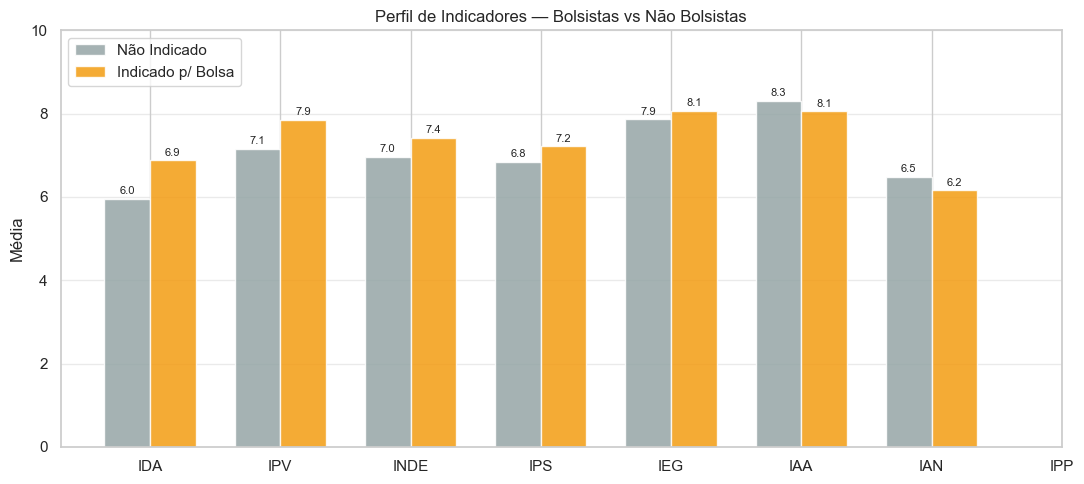

Distribuição de bolsistas:
INDICADO_BOLSA
False    728
True     132
Name: count, dtype: int64

Diferença (Bolsista - Não Bolsista):
IDA     0.93
IPV     0.71
INDE    0.45
IPS     0.37
IEG     0.20
IAA    -0.26
IAN    -0.32
IPP      NaN
Name: Diferença, dtype: float64


In [98]:
if 'INDICADO_BOLSA' in df.columns and df['INDICADO_BOLSA'].notna().sum() > 0:
    bolsa = df.groupby('INDICADO_BOLSA')[indicadores].mean().T
    bolsa.columns = ['Não Indicado', 'Indicado p/ Bolsa']
    bolsa['Diferença'] = bolsa['Indicado p/ Bolsa'] - bolsa['Não Indicado']
    bolsa_sorted = bolsa.sort_values('Diferença', ascending=False)

    fig, ax = plt.subplots(figsize=(11, 5))

    x = np.arange(len(bolsa_sorted))
    w = 0.35
    bars1 = ax.bar(x - w/2, bolsa_sorted['Não Indicado'], w,
                   label='Não Indicado', color='#95A5A6', edgecolor='white', alpha=0.85)
    bars2 = ax.bar(x + w/2, bolsa_sorted['Indicado p/ Bolsa'], w,
                   label='Indicado p/ Bolsa', color='#F39C12', edgecolor='white', alpha=0.85)

    ax.bar_label(bars1, fmt='%.1f', fontsize=8, padding=2)
    ax.bar_label(bars2, fmt='%.1f', fontsize=8, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels(bolsa_sorted.index)
    ax.set_title('Perfil de Indicadores — Bolsistas vs Não Bolsistas')
    ax.set_ylabel('Média')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    ax.set_ylim(0, 10)

    plt.tight_layout()
    plt.savefig('../reports/P11b_bolsistas.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Distribuição de bolsistas:")
    print(df['INDICADO_BOLSA'].value_counts())
    print("\nDiferença (Bolsista - Não Bolsista):")
    print(bolsa_sorted['Diferença'].round(2))

**Insights:**

- Bolsistas têm IDA , IPV e INDE superiores, a seleção está bem calibrada para identificar alunos com desempenho e desenvolvimento diferenciados.

- Exceção IAN: não-bolsistas têm IAN levemente maior, a bolsa prioriza trajetória e potencial, não apenas adequação formal ao nível curricular. Isso é metodologicamente correto.

- IPS de bolsistas é superior: condição psicossocial ligeiramente melhor nos bolsistas, pode indicar viés de seleção (famílias mais estáveis têm mais condições de sustentar a permanência no programa para receber bolsa).

- Recomendação: formalizar os critérios de seleção de bolsistas como um "score de elegibilidade" baseado nos pesos da P8. Isso tornaria o processo mais transparente e auditável.

### P11c: Crescimento da Base e Evolução Proporcional das Pedras

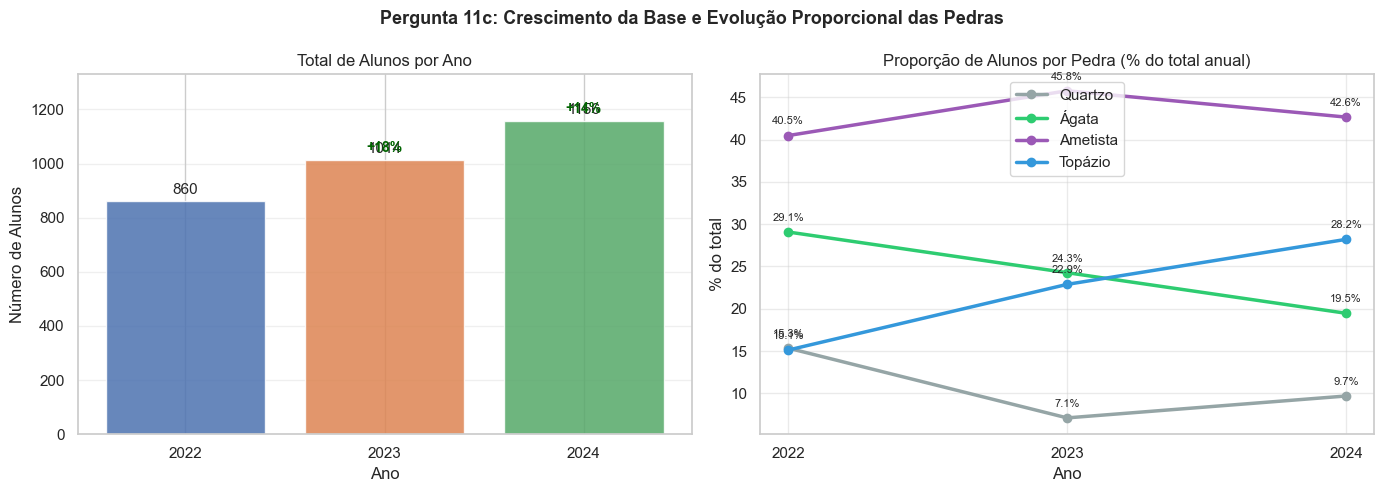

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 11c: Crescimento da Base e Evolução Proporcional das Pedras',
             fontsize=13, fontweight='bold')

# Crescimento absoluto da base
base_ano = df.groupby('ANO').size().reset_index(name='Total')
bars = axes[0].bar(base_ano['ANO'], base_ano['Total'],
                   color=CORES_ANOS, edgecolor='white', alpha=0.85)
axes[0].bar_label(bars, fontsize=11, padding=3)
for i in range(1, len(base_ano)):
    crescimento = (base_ano.iloc[i]['Total'] / base_ano.iloc[i-1]['Total'] - 1) * 100
    axes[0].text(base_ano.iloc[i]['ANO'], base_ano.iloc[i]['Total'] + 30,
                 f'+{crescimento:.0f}%', ha='center', fontsize=10,
                 color='darkgreen', fontweight='bold')
axes[0].set_title('Total de Alunos por Ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Número de Alunos')
axes[0].set_xticks([2022, 2023, 2024])
axes[0].set_ylim(0, base_ano['Total'].max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Proporção de cada Pedra por ano
pedra_prop = (df.groupby(['ANO', 'PEDRA'], observed=True)
               .size()
               .reset_index(name='Qtde'))
pedra_prop['Total_ano'] = pedra_prop.groupby('ANO')['Qtde'].transform('sum')
pedra_prop['Prop'] = pedra_prop['Qtde'] / pedra_prop['Total_ano'] * 100

for pedra, cor in zip(ordem_pedras, CORES_PEDRA):
    sub = pedra_prop[pedra_prop['PEDRA'] == pedra]
    axes[1].plot(sub['ANO'], sub['Prop'], marker='o',
                 label=pedra, color=cor, linewidth=2.5)
    for _, row in sub.iterrows():
        axes[1].annotate(f"{row['Prop']:.1f}%",
                         xy=(row['ANO'], row['Prop']),
                         xytext=(0, 8), textcoords='offset points',
                         ha='center', fontsize=8)

axes[1].set_title('Proporção de Alunos por Pedra (% do total anual)')
axes[1].set_xticks([2022, 2023, 2024])
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('% do total')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/P11c_crescimento_base.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- A base cresceu 18% em 2023 e mais 14% em 2024, expansão significativa mantendo qualidade dos indicadores.

- Topázio: proporção saltou de 15% (2022) para 29% (2024), dobrou a participação relativa. É o resultado mais positivo do programa.

- Ágata: caiu de 29% para 20%, redução proporcional consistente. Alunos estão migrando para pedras superiores.

- Quartzo: caiu de 15% para 10%, menos alunos no patamar mais crítico, mesmo com base crescendo.

- Implicação: apesar da estagnação do IDA médio, a composição da base está melhorando progressivamente. O programa está elevando mais alunos para as faixas superiores — resultado que a média agregada não captura.

---
# 5. Salvar Dataset Atualizado

In [100]:
# Salvar dataset com colunas criadas nesta sessão
colunas_novas = ['IAN_ADEQUADO', 'DEFASAGEM_IAN', 'GAP_IAA_IDA',
                 'IEG_FAIXA', 'IPS_FAIXA', 'RISCO',
                 'IDA_ALTO', 'IAA_ALTO', 'COMBO']

colunas_presentes = [c for c in colunas_novas if c in df.columns]

df.to_parquet('../data/processed/pede_consolidado.parquet', index=False)

print(f'\nNovas colunas adicionadas:')
for c in colunas_presentes:
    print(f'  • {c}')

print(f'\nShape final: {df.shape}')
print(f"\nDistribuição da variável RISCO:")
print(df['RISCO'].value_counts())
print(f"Taxa de risco: {df['RISCO'].mean()*100:.1f}%")


Novas colunas adicionadas:
  • IAN_ADEQUADO
  • DEFASAGEM_IAN
  • GAP_IAA_IDA
  • IEG_FAIXA
  • IPS_FAIXA
  • RISCO
  • IDA_ALTO
  • IAA_ALTO
  • COMBO

Shape final: (3030, 31)

Distribuição da variável RISCO:
RISCO
0    2272
1     758
Name: count, dtype: int64
Taxa de risco: 25.0%
